**HOUSE PRICE PREDICTION:**

using knowledge of ML to make model House price prediction which predict price of house on the base of different features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


**Loading DataSet:**

In [2]:
df = pd.read_csv('data.csv')
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


**Basic EDA to understand Data and Feature**

In [4]:
df.shape

(4600, 18)

In [5]:
df.info

<bound method DataFrame.info of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  c

**Statistical Summary**

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


**For Missing Values**

In [7]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

**To Check Duplication**

In [8]:
df.duplicated().sum()

np.int64(0)

**For Unique Values**

In [9]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

**Feature Engineering**

In [10]:
# Calculate overall square footage by combining living space and basement
df['total_sqft'] = df['sqft_above'] + df['sqft_basement']

In [11]:
# Number of rooms
# This shows the model the total "capacity" of the house
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [12]:
# Calculate House Age
# Models understand "20 years old" better than the year "2004"
df['year_sold'] = pd.to_datetime(df['date']).dt.year
df['house_age'] = df['year_sold'] - df['yr_built']

In [13]:
# Simplify Renovations
# Changes the year (like 1995) into a simple "Yes (1)" or "No (0)"
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

**Drop Unnecessary Column**

In [14]:
df = df.drop(['date', 'year_sold','country'], axis=1)

In [15]:
# List of old columns that are now represented by our new "Total" columns
cols_to_drop = [
    'sqft_above',    # Included in total_sqft
    'sqft_basement', # Included in total_sqft
    'bedrooms',      # Included in total_rooms
    'bathrooms',     # Included in total_rooms
    'yr_built',      # Included in house_age
    'yr_renovated'   # Included in is_renovated
]

# Drop them all at once
df = df.drop(columns=cols_to_drop)

print("Data is now clean and ready for the model!")

Data is now clean and ready for the model!


In [16]:
df.head

<bound method NDFrame.head of              price  sqft_living  sqft_lot  floors  waterfront  view  \
0     3.130000e+05         1340      7912     1.5           0     0   
1     2.384000e+06         3650      9050     2.0           0     4   
2     3.420000e+05         1930     11947     1.0           0     0   
3     4.200000e+05         2000      8030     1.0           0     0   
4     5.500000e+05         1940     10500     1.0           0     0   
...            ...          ...       ...     ...         ...   ...   
4595  3.081667e+05         1510      6360     1.0           0     0   
4596  5.343333e+05         1460      7573     2.0           0     0   
4597  4.169042e+05         3010      7014     2.0           0     0   
4598  2.034000e+05         2090      6630     1.0           0     0   
4599  2.206000e+05         1490      8102     2.0           0     0   

      condition                    street       city  statezip  total_sqft  \
0             3      18810 Densmore Ave

**Visualization oF exploratry Data:**

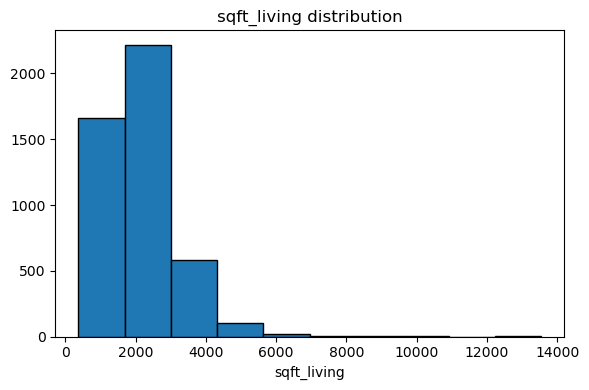

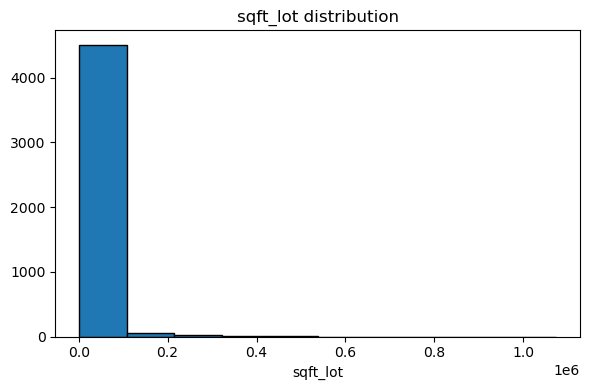

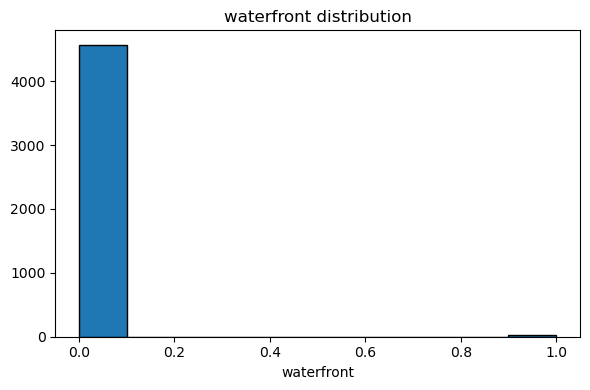

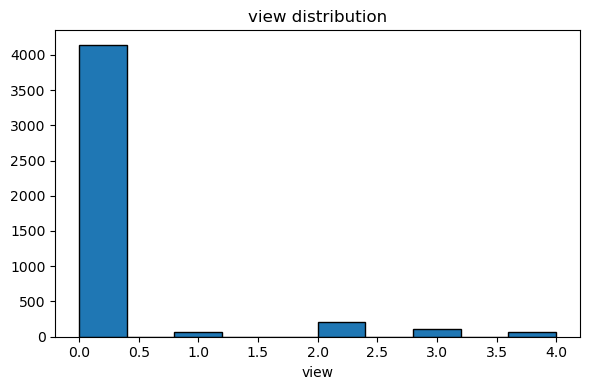

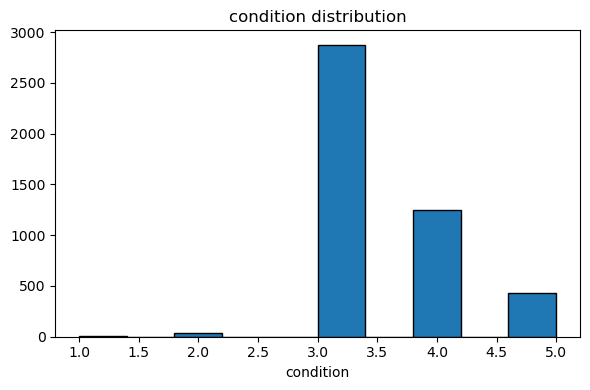

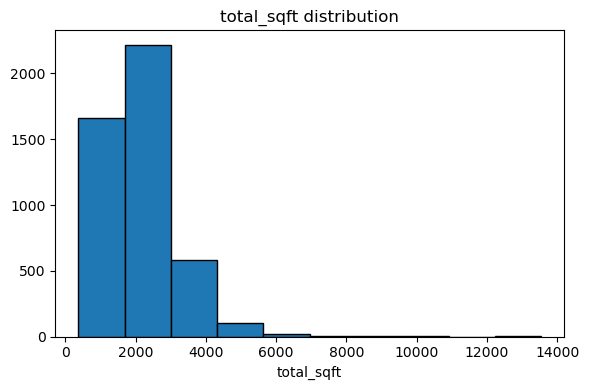

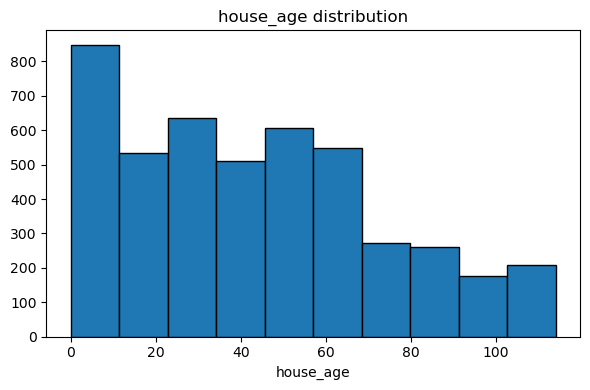

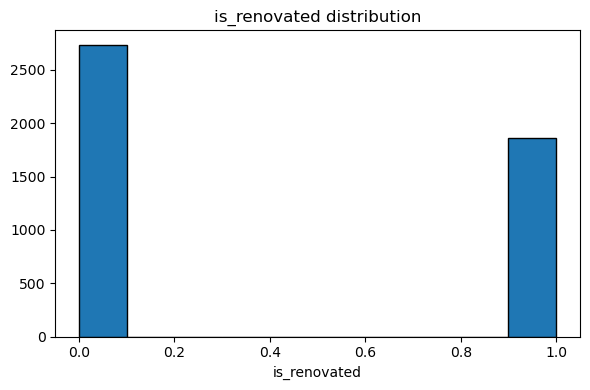

In [22]:
num_columns=df.select_dtypes(include=['int64'])
for i in num_columns:
    plt.figure(figsize=(6,4))
    plt.title(f"{i} distribution")
    plt.hist(df[i],edgecolor='black')
    plt.xlabel(f"{i}")
    plt.tight_layout()
    plt.show()

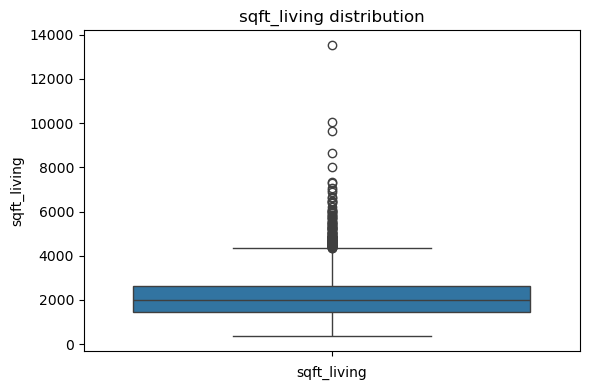

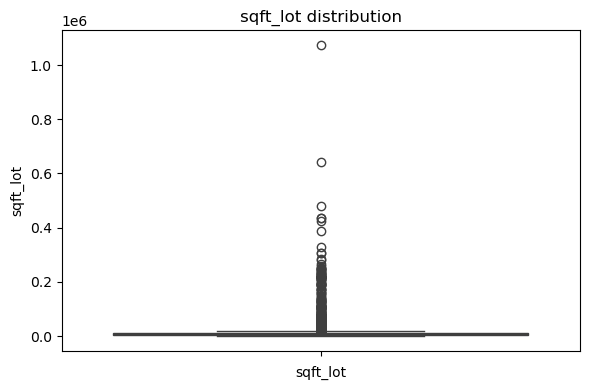

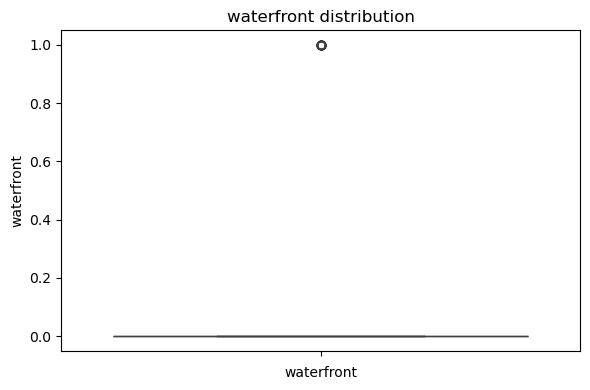

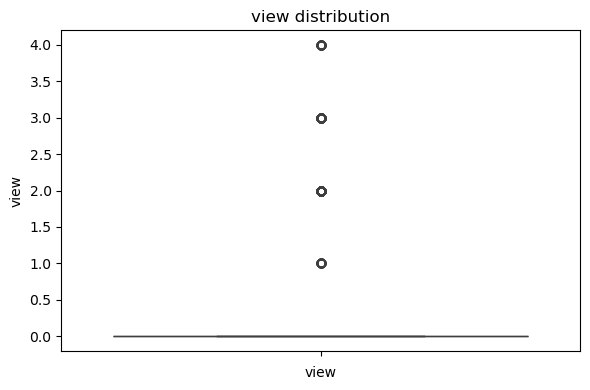

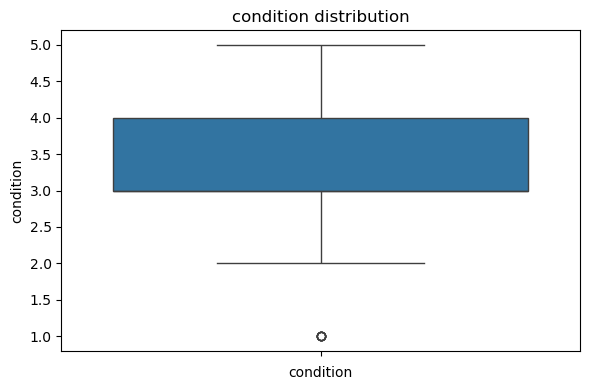

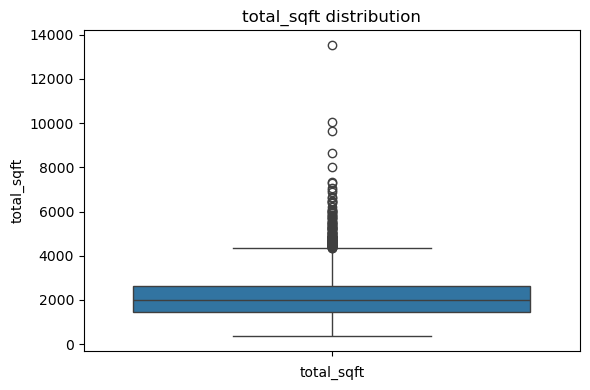

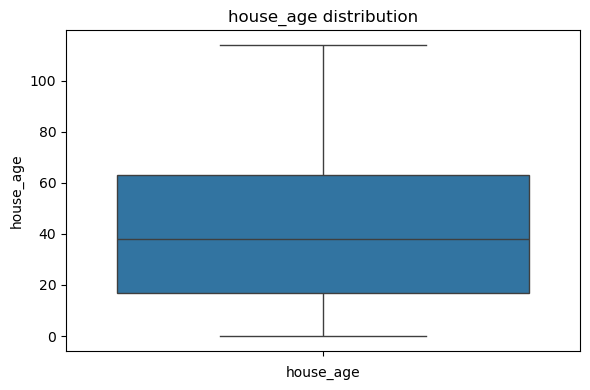

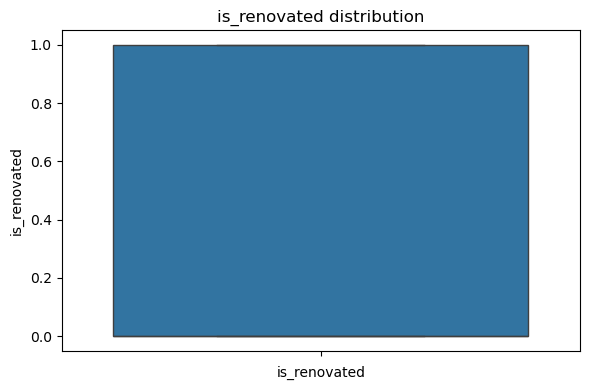

In [23]:
for i in num_columns:
    plt.figure(figsize=(6,4))
    plt.title(f"{i} distribution")
    sns.boxplot(df[i])
    plt.xlabel(f"{i}")
    plt.tight_layout()
    plt.show()

**Price vs Location**

In [34]:
categorical_cols=df.select_dtypes(include=['object'])
categorical_cols

,street,city,statezip
0,18810 Densmore Ave N,Shoreline,WA 98133
1,709 W Blaine St,Seattle,WA 98119
2,26206-26214 143rd Ave SE,Kent,WA 98042
3,857 170th Pl NE,Bellevue,WA 98008
4,9105 170th Ave NE,Redmond,WA 98052
...,...,...,...
4595,501 N 143rd St,Seattle,WA 98133
4596,14855 SE 10th Pl,Bellevue,WA 98007
4597,759 Ilwaco Pl NE,Renton,WA 98059
4598,5148 S Creston St,Seattle,WA 98178


In [35]:
a=df.groupby("city")[["price"]].mean()
a

,price
city,
Algona,2.072880e+05
Auburn,2.993404e+05
Beaux Arts Village,7.450000e+05
Bellevue,8.471807e+05
Black Diamond,3.396056e+05
Bothell,4.814419e+05
Burien,3.489472e+05
Carnation,5.087520e+05
Clyde Hill,1.321945e+06


**Graphical Presentation  of Price and Location**

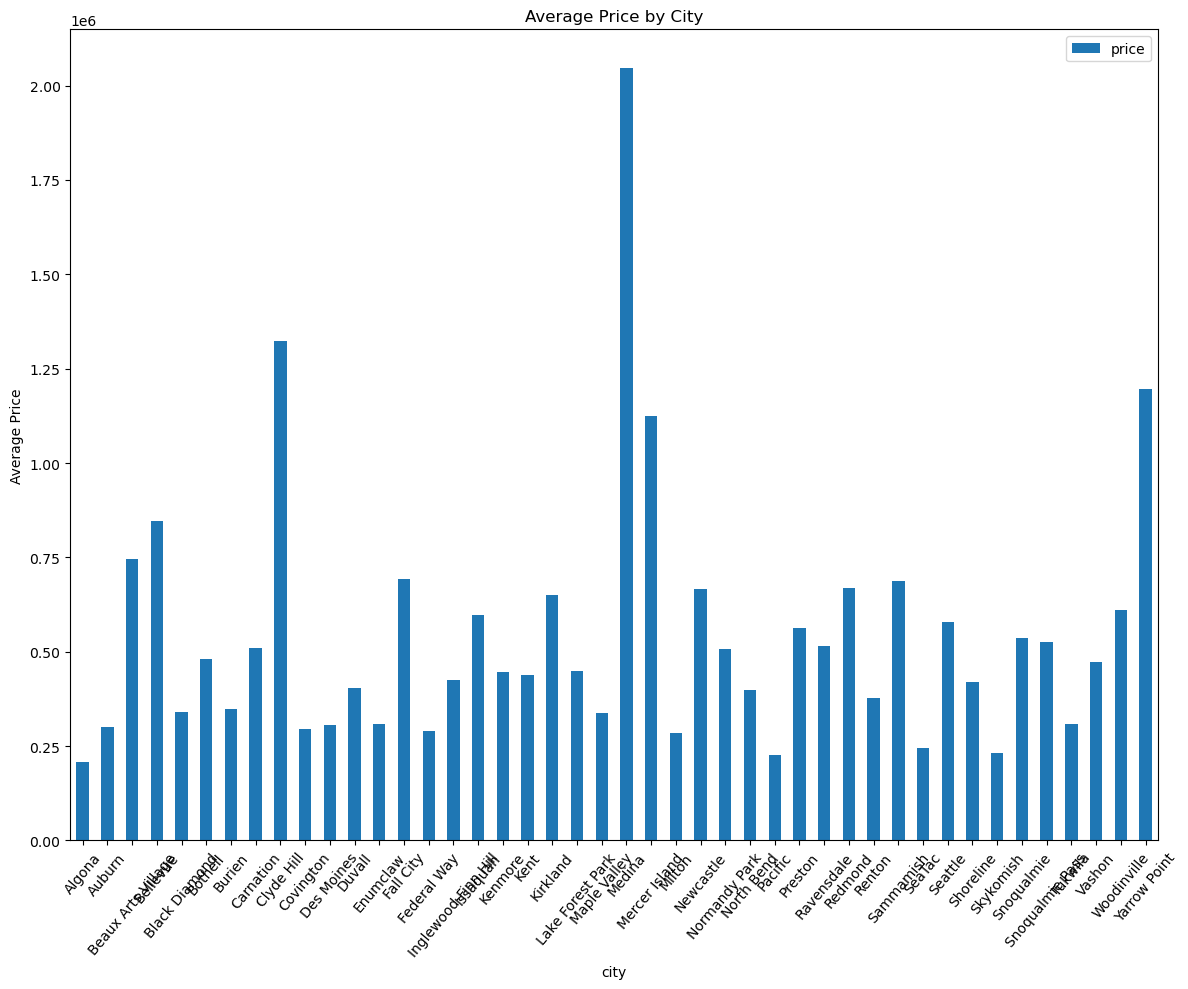

In [38]:
a.plot(kind="bar", figsize=(12,10), title="Average Price by City")
plt.ylabel("Average Price")
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [39]:
#show which feature effect too much
c=df.groupby("statezip")[["price"]].mean()

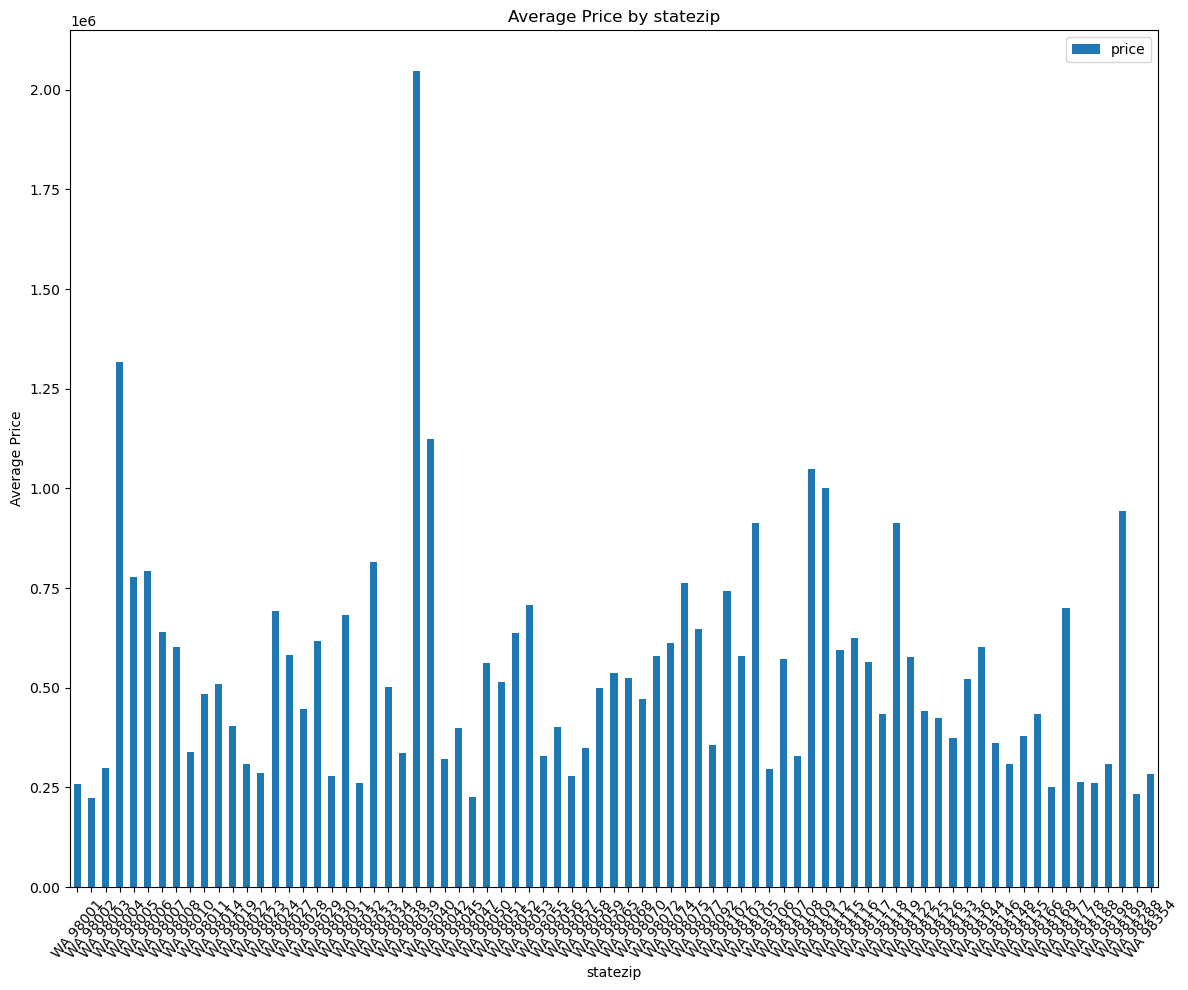

In [40]:
c.plot(kind="bar", figsize=(12,10), title="Average Price by statezip")
plt.ylabel("Average Price")
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [42]:
for i in categorical_cols:
    df[i]=le.fit_transform(df[i])

**Correlation Heatmap**

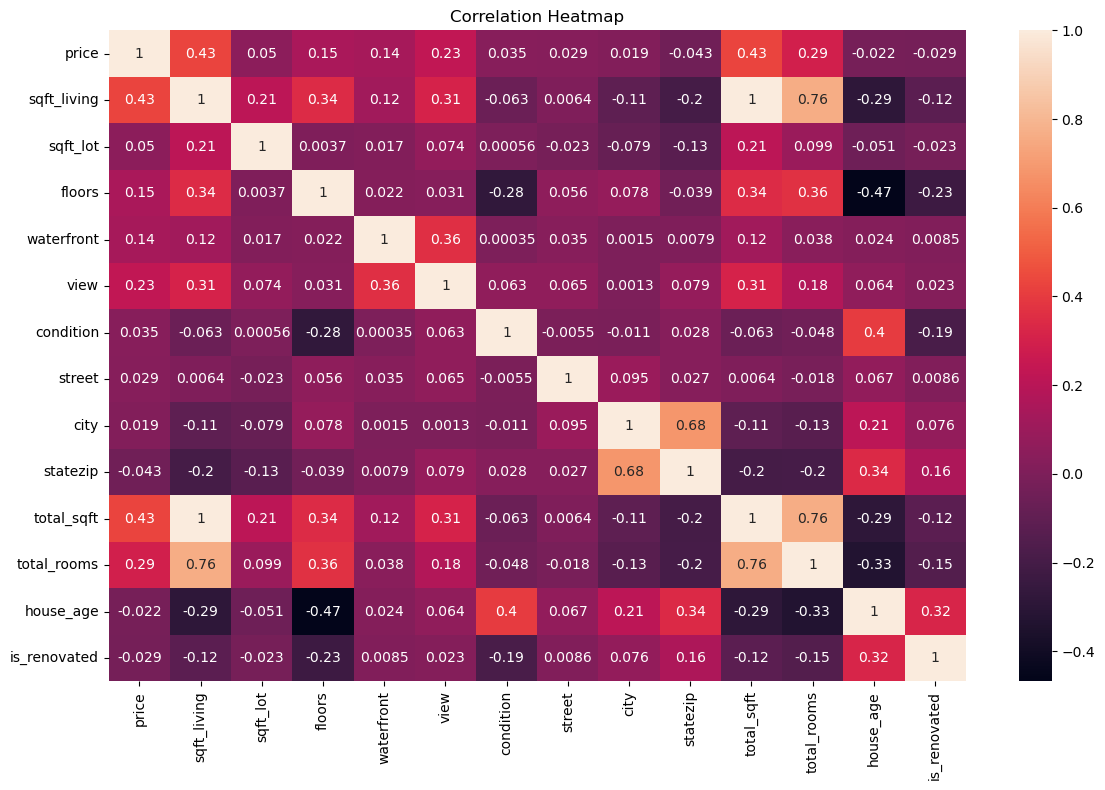

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [44]:
corr=df.corr()['price']
corr

price           1.000000
sqft_living     0.430410
sqft_lot        0.050451
floors          0.151461
waterfront      0.135648
view            0.228504
condition       0.034915
street          0.029366
city            0.018625
statezip       -0.043385
total_sqft      0.430410
total_rooms     0.294401
house_age      -0.021857
is_renovated   -0.028595
Name: price, dtype: float64

In [45]:
#sort Values in Ascending Order
corr_abs=corr.abs().sort_values(ascending=False)
corr_abs

price           1.000000
sqft_living     0.430410
total_sqft      0.430410
total_rooms     0.294401
view            0.228504
floors          0.151461
waterfront      0.135648
sqft_lot        0.050451
statezip        0.043385
condition       0.034915
street          0.029366
is_renovated    0.028595
house_age       0.021857
city            0.018625
Name: price, dtype: float64

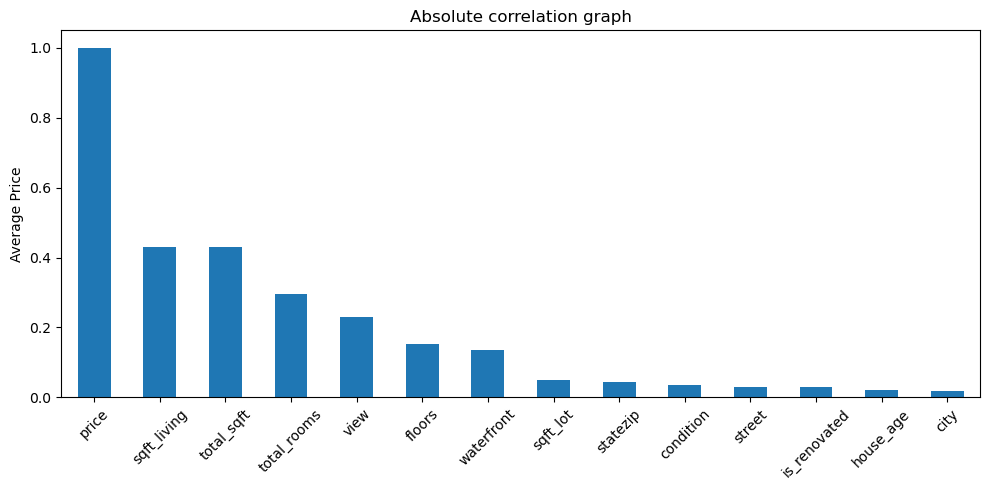

In [46]:
corr_abs.plot(kind='bar',figsize=(10,5), title="Absolute correlation graph")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
selected_features=corr_abs[corr_abs>=0.2].index
selected_features

Index(['price', 'sqft_living', 'total_sqft', 'total_rooms', 'view'], dtype='object')

In [48]:
final_df=df[selected_features]
final_df

,price,sqft_living,total_sqft,total_rooms,view
0,3.130000e+05,1340,1340,4.50,0
1,2.384000e+06,3650,3650,7.50,4
2,3.420000e+05,1930,1930,5.00,0
3,4.200000e+05,2000,2000,5.25,0
4,5.500000e+05,1940,1940,6.50,0
...,...,...,...,...,...
4595,3.081667e+05,1510,1510,4.75,0
4596,5.343333e+05,1460,1460,5.50,0
4597,4.169042e+05,3010,3010,5.50,0
4598,2.034000e+05,2090,2090,6.00,0


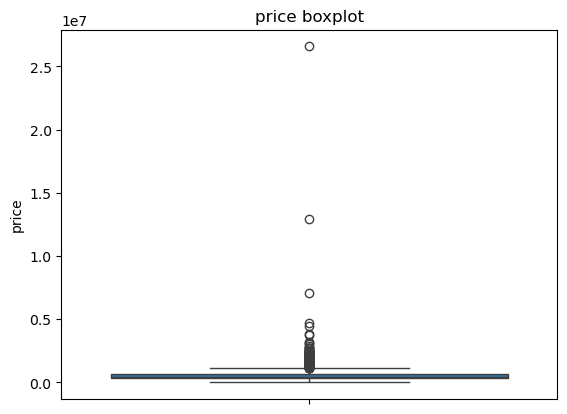

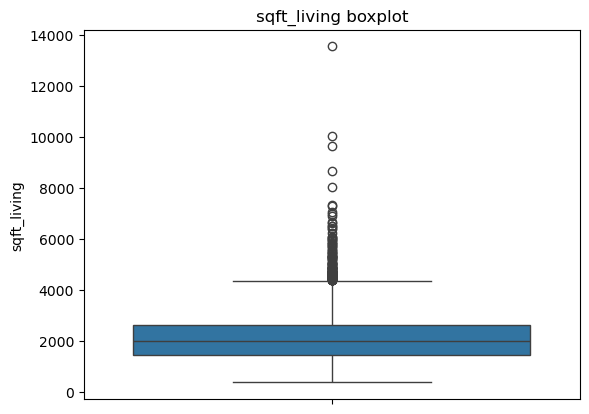

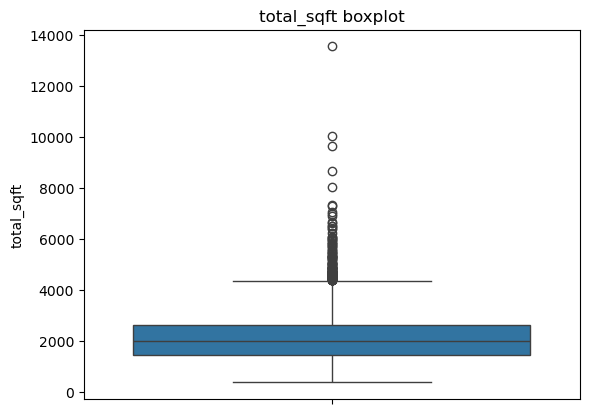

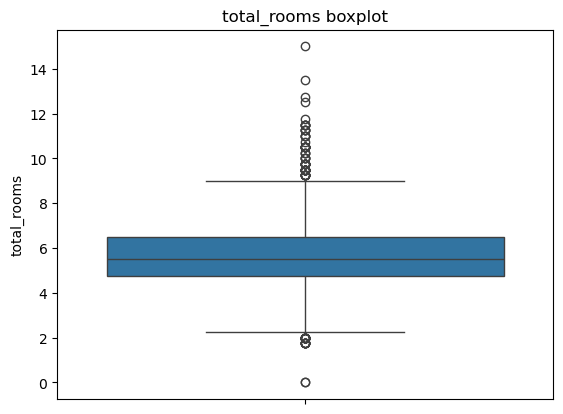

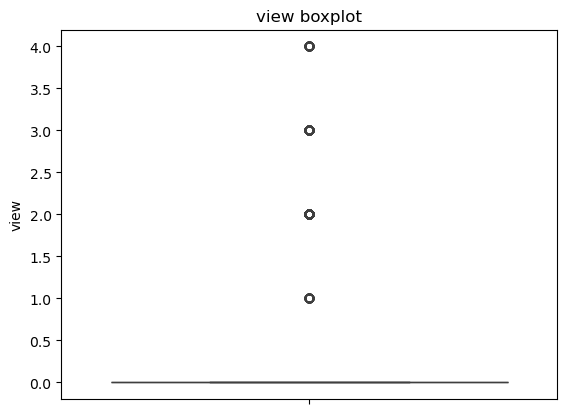

In [49]:
for i in selected_features:
    sns.boxplot(final_df[i])
    plt.title(f"{i} boxplot")
    plt.show()

**Outliers Handling**

In [50]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"Outliers removed from '{column}': {len(df) - len(df_filtered)} rows")
    return df_filtered

print(f"Original DataFrame shape: {df.shape}")

# Apply outlier removal to price (target variable)
df = remove_outliers_iqr(df, 'price')

# Apply outlier removal to other key numerical features that showed outliers in boxplots
for col in ['sqft_living', 'total_rooms', 'view']:
    df = remove_outliers_iqr(df, col)

print(f"DataFrame shape after outlier removal: {df.shape}")

Original DataFrame shape: (4600, 14)
Outliers removed from 'price': 240 rows
Outliers removed from 'sqft_living': 76 rows
Outliers removed from 'total_rooms': 17 rows
Outliers removed from 'view': 314 rows
DataFrame shape after outlier removal: (3953, 14)


**Spliting our Data**

In [51]:
X=df.drop(columns=['price'])
y=df['price']

In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)

**Scalling**

In [53]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [54]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

**Modeling**

In [55]:
from sklearn.ensemble import RandomForestRegressor
lr=RandomForestRegressor()

In [56]:
lr.fit(x_train_scaled,y_train)

RandomForestRegressor()

In [57]:
y_pred=lr.predict(x_test_scaled)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")


MAE  : 81518.84
RMSE : 118575.63
R²   : 0.682
